In [218]:
import math

class Value:
    def __init__(self,data,_children=(),_op='',label=""):
        self.data = data
        self.grad = 0.0
        self._prev = _children
        self._op = _op
        self.label = label
        self._backward = lambda:None

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self,other),"+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out 
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),"*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __repr__(self):
        return f"Value: {self.data}"
    
    def __iter__(self):
        for child in self._prev:
            yield child

    def __sub__(self, other):
        return self + (-other)

    def __neg__(self):
        return self * -1
    
    def __pow__(self, other):
        assert isinstance(other,(int,float)), "only supporting int/float powers for now "
        out = Value(self.data**other,(self,),f"**{other}")

        def _backward():
            self.grad = other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t,(self,),"tanh")

        def _backward():
            self.grad = (1-t**2) * out.grad

        out._backward = _backward
        return out
    
        

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()



In [219]:
v1 = Value(2);v1.label = 'v1'
v2 = Value(3);v2.label = 'v2'
v3 = v1+v2;v3.label = 'v3'
b = Value(4) ;b.label = 'b'
v4 = v3+b ; v4.label = 'v4'
v5 = v4.tanh()
v5; v5.label = "v5"

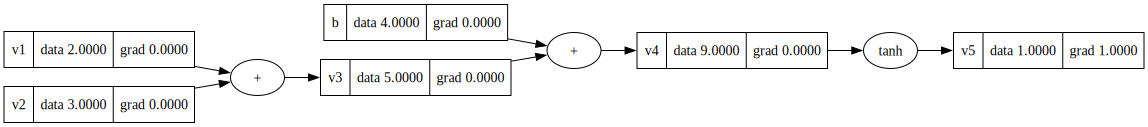

In [220]:
v5.backward()
draw_dots(v5)

In [221]:
from graphviz import Digraph

def trace(root):
    nodes,edges  = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            # print("\naddding this to node ",v)
            # print("Node",nodes)
            for child in v._prev:
                # print("\nadding these to edges",child,v)
                edges.add((child,v))
                # print("Edges",edges)
                build(child)
    build(root)
    return nodes,edges


def draw_dots(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) #LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph,create a reactangular ('recored') node for it 
        dot.node(name=uid,label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it 
            dot.node(name = uid + n._op,label = n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2)) + n2._op )
    return dot



In [224]:
import random
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for i in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # wx+b 

        # act = sum(self.b,(wi*xi for wi,xi in zip(self.w,x))) 
        act = self.b
        for wi,xi in zip(self.w,x):
            act += wi*xi
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]        
    

    def state_dict(self):
        return {
            "weights":self.w,
            "bias":[self.b]
        }

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
    def state_dict(self):
        return {k:v for neuron in self.neurons for k,v in neuron.state_dict().items()}
    

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [l for layer in self.layers for l in layer.parameters()]
    
    def state_dict(self):
        return {k:v for layer in self.layers for k,v in layer.state_dict().items()}


In [225]:
x = [1.0,2.0]
n = MLP(3,[4,4,1])
n(x)

Value: -0.9146042014643079

In [226]:
len(n.parameters()) #,n.state_dict()

41

In [227]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

y_pred = [n(x) for x in xs]
y_pred

[Value: -0.9512345562318933,
 Value: -0.9436990619846322,
 Value: -0.8199638151887552,
 Value: -0.9513073139323296]

In [228]:
loss = sum((yp-ya)**2 for ya,yp in zip(ys,y_pred))
loss

Value: 7.650499350302075

In [229]:
loss.backward()
for p in n.parameters():
    p.data += -0.001 * p.grad

y_pred = [n(x) for x in xs]
loss = sum([(ygt - yout)**2  for ygt,yout in zip(y_pred,ys)])
loss


Value: 7.648230758996023

In [230]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yp-ya)**2 for ya,yp in zip(ys,ypred))

    #zero_grad()
    for p in n.parameters():
        p.grad = 0.0
    #backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k,loss.data)

0 7.648230758996023
1 7.513598070577343
2 7.246951561156708
3 6.5852727286736314
4 4.653169155168763
5 3.286279870730027
6 2.644433611062605
7 1.992773426812973
8 1.5690510252096688
9 0.9509797645407159
10 0.4876819487159234
11 0.27870886610011514
12 0.2199255251076257
13 0.18025457989031607
14 0.15157375108476717
15 0.1300607500769226
16 0.11343640655223086
17 0.10026895838042053
18 0.08962168497912794
19 0.08086007749366433


In [231]:
y_preds = []
for pred in ypred:
    if pred.data>0.5:
        y_preds.append(1)        
    else:
        y_preds.append(-1)        
y_preds

[1, -1, -1, 1]

In [232]:
y_preds == ys 

True

In [233]:
import pandas as pd

df = pd.read_csv(r"D:\Test\Python\Deep Learning\micrograd\files\data.csv")
df.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [241]:
Xs = df[['area']].values.tolist()
y = df['price']
Xs,y

([[2600], [3000], [3200], [3600], [4000]],
 0    550000
 1    565000
 2    610000
 3    680000
 4    725000
 Name: price, dtype: int64)

In [242]:
[x for x in Xs]

[[2600], [3000], [3200], [3600], [4000]]

In [243]:
y_pred = [n(x) for x in Xs]
y_pred


[Value: 0.9092915450677539,
 Value: 0.9092915450677539,
 Value: 0.9092915450677539,
 Value: 0.9092915450677539,
 Value: 0.9092915450677539]

In [244]:
for pred in y_pred:
    print(pred)

Value: 0.9092915450677539
Value: 0.9092915450677539
Value: 0.9092915450677539
Value: 0.9092915450677539
Value: 0.9092915450677539


In [246]:
y

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [247]:
# Normalize your data before training
df['area_norm'] = (df['area'] - df['area'].min()) / (df['area'].max() - df['area'].min())

# Now use the normalized data
Xs = df[['area_norm']].values.tolist()

# Re-run your model prediction
y_pred = [n(x) for x in Xs]

In [248]:
y_pred

[Value: -0.8439100646900535,
 Value: -0.7877379354297386,
 Value: -0.7590032808128486,
 Value: -0.7019441666758963,
 Value: -0.6465150891010909]